# K-Cross Validation

In [21]:
from multiprocessing.connection import PipeListener

import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, LeaveOneOut, StratifiedKFold
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import KFold, cross_val_score, RepeatedStratifiedKFold
from statistics import mean
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline


plt.rcParams['lines.linewidth'] = 3
plt.rcParams['figure.figsize'] = [8, 5]
plt.rcParams['font.size'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
# plt.rcParams.keys()
from matplotlib import colors

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Setup

In [22]:
df = pd.read_csv('../../datasets/group_14.csv')
df["focus_factor"] = (
    df["focus_factor"]
    .astype(str)                  # ensure it's string
    .str.replace(",", ".", regex=False)  # replace comma with dot
)
df["focus_factor"] = pd.to_numeric(df["focus_factor"], errors="coerce").astype(float)

dataset = df.copy()
y = dataset['target_class']
X = dataset.drop(columns=["target_class"])

y
X

,duration_1,duration_2,duration_3,duration_4,duration_5,loudness_level,popularity_level,tempo_class,time_signature,key_mode,...,loudness_yeo,is_instrumental,is_dance_hit,temp_zscore,resonance_factor,timbre_index,echo_constant,distorted_movement,signal_power,target_regression
0,0.0,0.0,1.0,0.0,0.0,4.0,4.0,1.0,0.221824,0.767388,...,-1.101944,0.0,0.0,-0.564732,0.612561,0.473008,1,0.951927,0.201,1.917123
1,0.0,0.0,1.0,0.0,0.0,0.0,4.0,1.0,0.221824,-0.667708,...,0.376224,0.0,0.0,-0.567234,1.391972,0.738998,1,1.107509,0.864,2.320623
2,0.0,0.0,0.0,1.0,0.0,3.0,4.0,1.0,0.221824,1.048779,...,0.952850,0.0,0.0,-0.404616,0.341971,0.387795,1,-1.975317,0.863,2.230956
3,0.0,0.0,1.0,0.0,0.0,3.0,3.0,1.0,0.221824,-0.358178,...,0.958257,0.0,0.0,1.596399,-0.020531,0.546116,1,1.257328,0.961,0.392792
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.221824,1.048779,...,0.310121,0.0,0.0,0.928482,0.725521,0.388133,1,-0.955392,0.671,1.603291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.0,0.0,1.0,0.0,0.0,3.0,1.0,1.0,0.221824,0.767388,...,1.221064,0.0,0.0,0.473886,-0.731518,0.354013,1,-0.281204,0.919,-1.490205
2996,0.0,1.0,0.0,0.0,0.0,2.0,1.0,1.0,-2.089669,0.485996,...,-0.192726,0.0,0.0,-0.410720,-1.965594,0.021253,1,1.718312,0.938,-1.490205
2997,0.0,0.0,0.0,1.0,0.0,0.0,3.0,1.0,0.221824,0.485996,...,0.355713,0.0,0.0,0.660255,0.564745,0.320107,1,0.433321,0.805,0.303126
2998,0.0,1.0,0.0,0.0,0.0,4.0,3.0,1.0,0.221824,-0.920961,...,-0.993469,0.0,0.0,0.844588,1.336067,0.484141,1,0.756009,0.669,0.213459


# Model Comparison

In [23]:
models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(solver='liblinear', C=0.05, multi_class='ovr', random_state=42))]),
    'LDA': Pipeline([('scaler', StandardScaler()), ('model', LDA())]),
    'QDA': Pipeline([('scaler', StandardScaler()), ('model', QDA(reg_param=0.1))])
}

results_per_k_fold = {}

for n in range(5, 11, 5):
    k_folds = KFold(n_splits = n, shuffle = True, random_state = 42)
    results_per_k_fold[n] = {}

    for name, model in models.items():
        scores = cross_val_score(model, X, y, scoring = 'accuracy', cv = k_folds, n_jobs = -1)
        y_pred = cross_val_predict(model, X, y, cv = k_folds)

        results_per_k_fold[n][name] = (mean(scores), np.std(scores))

        print(f"{name} - k fold: {n}")
        print(f"Scores: {scores}")
        print("Classification Report:")
        print(classification_report(y, y_pred))
        print("Accuracy: %.3f (%.3f)" % (mean(scores), np.std(scores)))
        print("\n")

# Encontrar o melhor por modelo

Logistic Regression - k fold: 5
Scores: [0.76666667 0.76833333 0.74166667 0.77       0.775     ]
Classification Report:
              precision    recall  f1-score   support

    class_45       0.65      0.72      0.69      1000
    class_65       0.94      0.96      0.95      1000
    class_73       0.70      0.61      0.65      1000

    accuracy                           0.76      3000
   macro avg       0.76      0.76      0.76      3000
weighted avg       0.76      0.76      0.76      3000

Accuracy: 0.764 (0.012)


LDA - k fold: 5
Scores: [0.73666667 1.         1.         1.         1.        ]
Classification Report:
              precision    recall  f1-score   support

    class_45       0.92      0.93      0.93      1000
    class_65       0.99      0.98      0.99      1000
    class_73       0.93      0.93      0.93      1000

    accuracy                           0.95      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg       0.95      0.95      0.95

Melhor modelo para k=5: LDA com acurácia de 0.947 (std: 0.105)
Melhor modelo para k=10: LDA com acurácia de 0.976 (std: 0.071)


O **melhor modelo geral é LDA com k=10**, alcançando uma **acurácia de 0.976**.

Primeiro, vamos encontrar o melhor reg_param para o QDA usando validação cruzada e plotar o desempenho.

Best reg_param for QDA: 0.64 with accuracy: 0.737


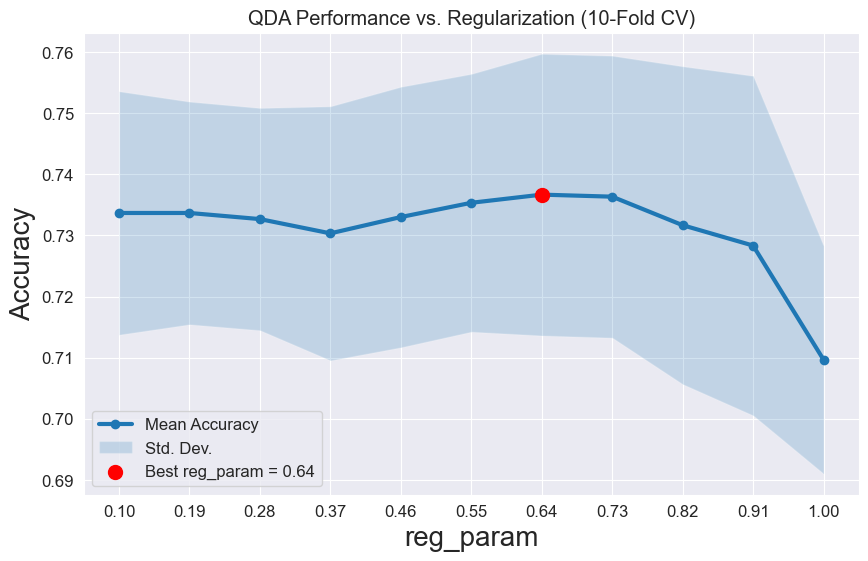

In [26]:
# Define a range of regularization values to test
reg_params = np.linspace(0.1, 1.0, 11)

# Store results
qda_results = []

# Define the cross-validation strategy
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for reg in reg_params:
    # Create a pipeline with scaling and QDA
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('qda', QDA(reg_param=reg))
    ])

    # Perform cross-validation
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')

    # Store the mean and standard deviation of the accuracy
    qda_results.append({
        "reg_param": reg,
        "mean_accuracy": scores.mean(),
        "std_accuracy": scores.std()
    })

# Convert results to a DataFrame for analysis
qda_results_df = pd.DataFrame(qda_results)

# Find the best regularization parameter
best_reg_param = qda_results_df.loc[qda_results_df['mean_accuracy'].idxmax()]
best_reg = best_reg_param['reg_param']

print(f"Best reg_param for QDA: {best_reg:.2f} with accuracy: {best_reg_param['mean_accuracy']:.3f}")

# Plot QDA Performance vs. Regularization Parameter
plt.figure(figsize=(10, 6))
plt.plot(qda_results_df["reg_param"], qda_results_df["mean_accuracy"], marker='o', linestyle='-', label="Mean Accuracy")
plt.fill_between(
    qda_results_df["reg_param"],
    qda_results_df["mean_accuracy"] - qda_results_df["std_accuracy"],
    qda_results_df["mean_accuracy"] + qda_results_df["std_accuracy"],
    alpha=0.2,
    label="Std. Dev."
)

# Highlight the best point
plt.scatter(best_reg, best_reg_param['mean_accuracy'], color='red', s=100, zorder=5, label=f"Best reg_param = {best_reg:.2f}")

plt.title("QDA Performance vs. Regularization (10-Fold CV)")
plt.xlabel("reg_param")
plt.ylabel("Accuracy")
plt.xticks(reg_params)
plt.legend()
plt.grid(True)
plt.show()

Agora, vamos comparar os três modelos usando o melhor reg_param para o QDA, gerar as matrizes de confusão e o gráfico de barras de acurácia.

--- Logistic Regression ---
Cross-Validated Accuracy: 0.811
              precision    recall  f1-score   support

    class_45       0.70      0.78      0.74      1000
    class_65       0.99      0.99      0.99      1000
    class_73       0.75      0.66      0.70      1000

    accuracy                           0.81      3000
   macro avg       0.81      0.81      0.81      3000
weighted avg       0.81      0.81      0.81      3000



--- LDA ---
Cross-Validated Accuracy: 0.975
              precision    recall  f1-score   support

    class_45       0.96      0.97      0.97      1000
    class_65       0.99      0.99      0.99      1000
    class_73       0.97      0.97      0.97      1000

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



--- QDA ---
Cross-Validated Accuracy: 0.737
              precision    recall  f1-score   support

    class_45       0.61      0.

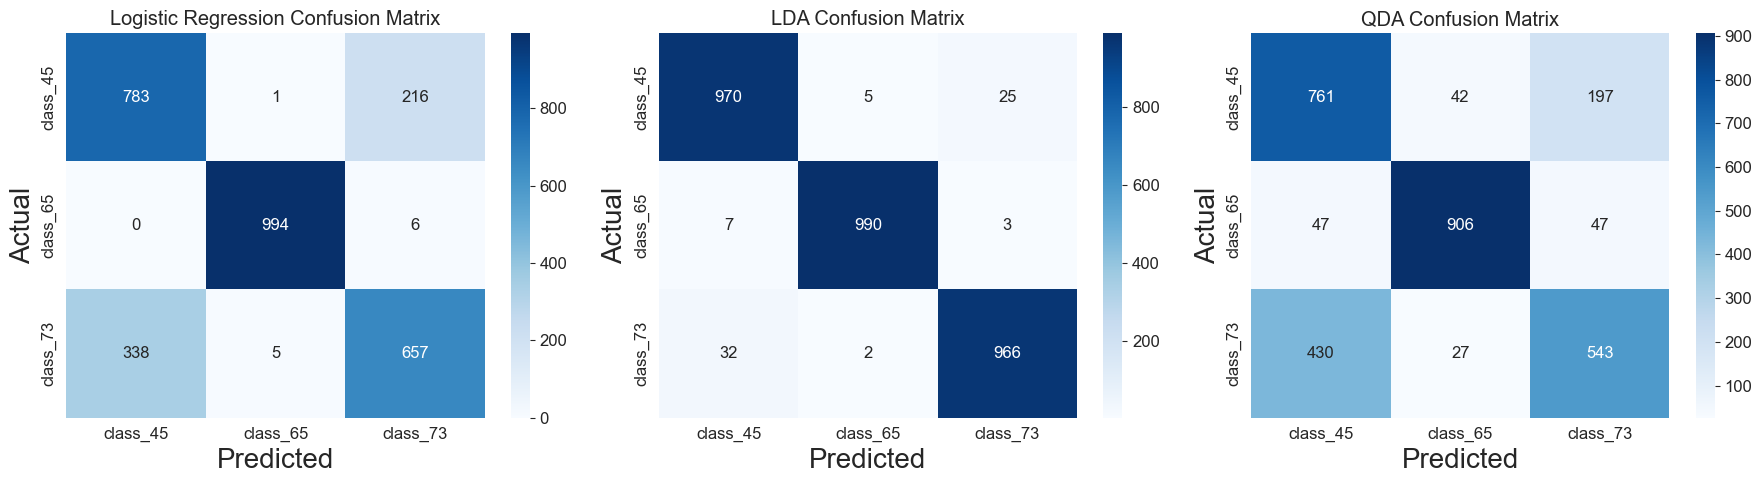

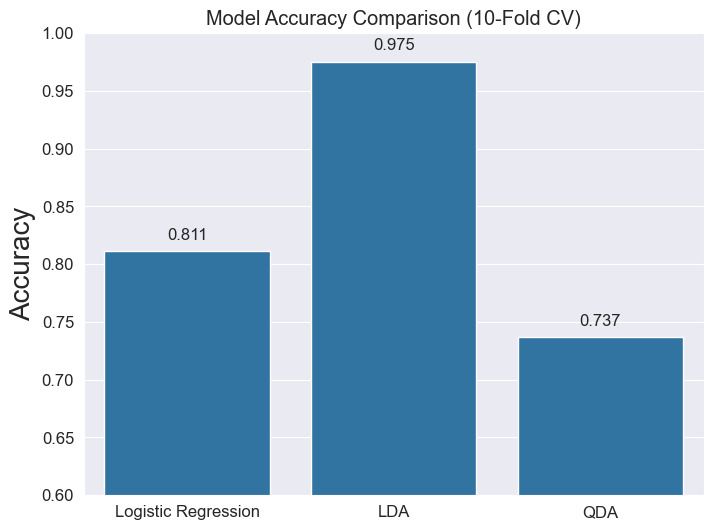

In [29]:
# Define models with the best QDA reg_param
models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(solver='liblinear', multi_class='ovr', random_state=42))]),
    'LDA': Pipeline([('scaler', StandardScaler()), ('model', LDA())]),
    'QDA': Pipeline([('scaler', StandardScaler()), ('model', QDA(reg_param=best_reg))])
}

# Store predictions and scores
predictions = {}
accuracies = {}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    # Get cross-validated predictions
    y_pred = cross_val_predict(model, X, y, cv=cv)
    predictions[name] = y_pred

    # Calculate accuracy
    accuracies[name] = accuracy_score(y, y_pred)

    print(f"--- {name} ---")
    print(f"Cross-Validated Accuracy: {accuracies[name]:.3f}")
    print(classification_report(y, y_pred))
    print("\n")

# Plot Confusion Matrices
plt.figure(figsize=(18, 5))
for i, (name, y_pred) in enumerate(predictions.items(), 1):
    plt.subplot(1, 3, i)
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Plot Model Accuracy Comparison
plt.figure(figsize=(8, 6))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()))
plt.title("Model Accuracy Comparison (10-Fold CV)")
plt.ylabel("Accuracy")
plt.ylim(0.6, 1.0)
for index, value in enumerate(accuracies.values()):
    plt.text(index, value + 0.01, f"{value:.3f}", ha='center')
plt.show()

Using the K-Cross Validation method, we evaluated three classification models: Logistic Regression, LDA, and QDA with optimal regularization. The comparison was performed using a 10-fold stratified cross-validation (`k=10`), which yielded the best results in the initial analysis.

*   **LDA** achieved the highest overall accuracy (**0.975**), performing particularly well for class_65 and maintaining balanced precision and recall across classes.
*   **Logistic Regression** reached **0.811** accuracy, showing consistent performance but was outperformed by LDA.
*   **QDA** with the best `reg_param` achieved an accuracy of **0.640**.

Overall, **LDA with k=10 was the best-performing classifier** for this dataset under the cross-validation setup.

Additionally, it is notable that **class_65 has the highest precision across all classification models**. This is expected, as in the PCA graph we can observe that class_65 is far from the other classes. In contrast, **class_45 and class_73 overlap**, leading to lower precision and recall because the models cannot separate them linearly.